In [16]:
nst = {3: 0.6571266651153564, 5: 1.200047254562378, 10: 3.8573341369628906, 30: 33.69472527503967, 50: 106.34372687339783}
kst = {1: 0.7728307247161865, 2: 0.7054648399353027, 5: 1.492445945739746, 10: 3.9591236114501953, 20: 19.748162031173706}

import numpy as np
import matplotlib.pyplot as plt



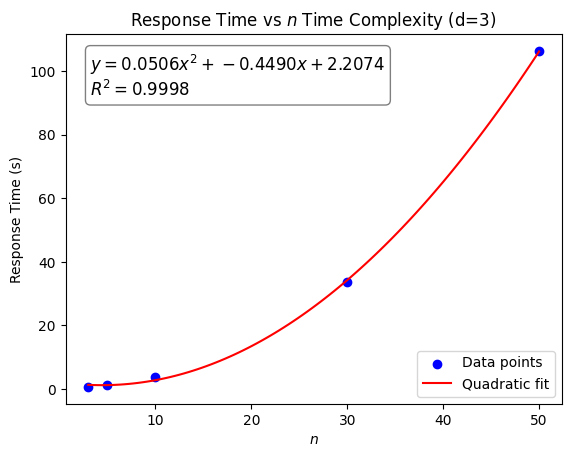

In [34]:

# Set the plot theme to light
plt.style.use('default')

# Extract x (keys) and y (values) from nst dictionary
x = np.array(list(nst.keys()))
y = np.array(list(nst.values()))

# Fit a quadratic curve (degree 2)
coeffs = np.polyfit(x, y, 2)
p = np.poly1d(coeffs)

# Calculate R-squared
y_pred = p(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# Generate points for the fitted line
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = p(x_fit)

# Create the scatterplot
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x_fit, y_fit, color='red', label='Quadratic fit')

# Format the equation and R-squared for display
equation = f"$y = {coeffs[0]:.4f}x^2 + {coeffs[1]:.4f}x + {coeffs[2]:.4f}$"
r2_text = f"$R^2 = {r_squared:.4f}$"
full_text = f"{equation}\n{r2_text}"

plt.text(0.05, 0.95, full_text, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.xlabel('$n$')
plt.ylabel('Response Time (s)')
plt.title('Response Time vs $n$ Time Complexity (d=3)')
plt.legend()
plt.savefig('time_complexity_n.png')
plt.show()


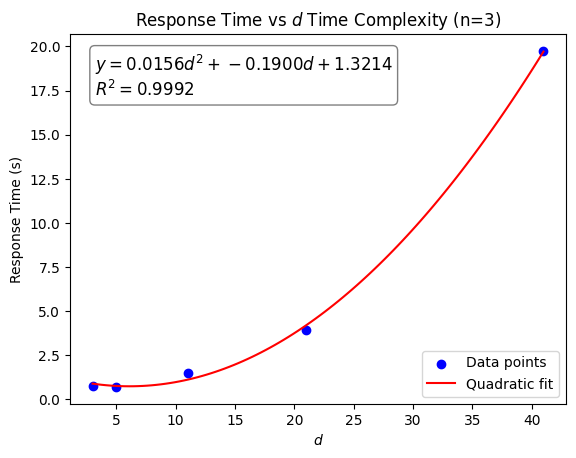

In [35]:

# Extract k and y from kst dictionary, then calculate d = 2k + 1
k_vals = np.array(list(kst.keys()))
x = 2 * k_vals + 1
y = np.array(list(kst.values()))

# Fit a quadratic curve (degree 2)
coeffs = np.polyfit(x, y, 2)
p = np.poly1d(coeffs)

# Calculate R-squared
y_pred = p(x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

# Generate points for the fitted line
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = p(x_fit)

# Create the scatterplot
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x_fit, y_fit, color='red', label='Quadratic fit')

# Format the equation and R-squared for display
equation = f"$y = {coeffs[0]:.4f}d^2 + {coeffs[1]:.4f}d + {coeffs[2]:.4f}$"
r2_text = f"$R^2 = {r_squared:.4f}$"
full_text = f"{equation}\n{r2_text}"

plt.text(0.05, 0.95, full_text, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.xlabel('$d$')
plt.ylabel('Response Time (s)')
plt.title('Response Time vs $d$ Time Complexity (n=3)')
plt.legend()
plt.savefig('time_complexity_d.png')
plt.show()


<llm-snippet-file>DataAnalysis.ipynb</llm-snippet-file>


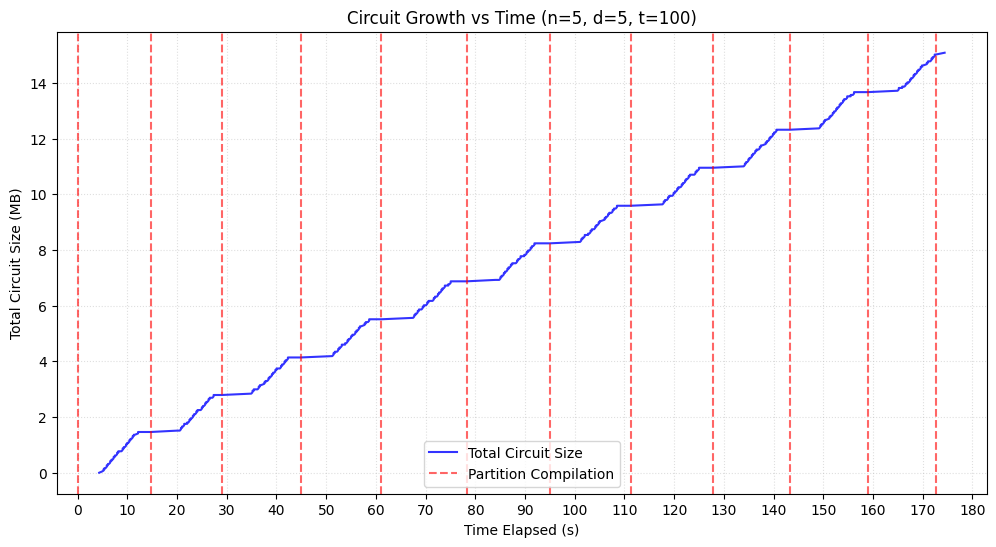

In [36]:
import re
import matplotlib.pyplot as plt

times_elapsed = []
circuit_sizes_mb = []
partition_markers = []

# Parse the file to extract data points and identify when partitions start
with open('t_against_len.txt', 'r') as f:
    last_data_point_time = 0.0
    first_partition_found = False

    for line in f:
        # Match data rows: Index, Time Taken, Time Elapsed, Total Circuit Size (bytes), ...
        # Example: 1, 0.02537751, 0.63249707, 265, ...
        match_data = re.match(r'^\s*(\d+),\s*[\d\.]+,\s*([\d\.]+),\s*(\d+),', line)
        if match_data:
            current_time = float(match_data.group(2))
            size_bytes = int(match_data.group(3))

            times_elapsed.append(current_time)
            # Convert bytes to MB (1024 * 1024)
            circuit_sizes_mb.append(size_bytes / (1024 * 1024))
            last_data_point_time = current_time

        # Match partition tree generation messages
        if "layer tree generation time" in line:
            if not first_partition_found:
                # The first partition marker should be at x=0
                partition_markers.append(0.0)
                first_partition_found = True
            else:
                # Subsequent markers go at the end of the previous data point
                partition_markers.append(last_data_point_time)

plt.figure(figsize=(12, 6))
plt.plot(times_elapsed, circuit_sizes_mb, label='Total Circuit Size', color='blue', alpha=0.8)

# Plot vertical lines to denote partition boundaries
for i, marker_time in enumerate(partition_markers):
    label = 'Partition Compilation' if i == 0 else ""
    plt.axvline(x=marker_time, color='red', linestyle='--', alpha=0.6, label=label)

plt.xlabel('Time Elapsed (s)')
plt.ylabel('Total Circuit Size (MB)')
plt.xticks(np.arange(0, max(times_elapsed)+10, step=10))
plt.title('Circuit Growth vs Time (n=5, d=5, t=100)')
plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.legend()
plt.savefig('circuit_growth_with_partitions.png')
plt.show()
